# Setup

Dependencias: java>=11 & python>=3.8

Install java jdk 11

```bash
> apt-get install openjdk-11-jdk
```

Install python-terrier

```bash
> pip install python-terrier
```



# Documentación oficial

https://pyterrier.readthedocs.io

# Inicialización de Terrier

In [ ]:
import pandas as pd
import pyterrier as pt
if not pt.java.started():
  pt.java.init()

Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


### Indexación de collecciones formadas con tags

Formato TREC

```xml
<DOC>
<DOCNO>DOC-001</DOCNO>
<TITLE>Título del documento</TITLE>
<TEXT>Contenido del documento...</TEXT>
</DOC>

<DOC>
<DOCNO>DOC-002</DOCNO>
...
</DOC>
´´´

In [22]:
# https://pyterrier.readthedocs.io/en/latest/terrier/indexing.html

files = pt.io.find_files("single_file_trec_collection/")

# crear un indexador especialiado en formato TREC

# indexer = pt.IterDictIndexer(stemmer='SpanishSnowballStemmer', stopwords=None)
# indexer = pt.IterDictIndexer("./index", stopwords=['a', 'an', 'the'])

indexer = pt.TRECCollectionIndexer("./custom_trec_index",  verbose=True, overwrite=True)

# Escanea los documentos, los tokeniza y escribe los archivos binarios en el disco
indexref = indexer.index(files)

# Carga estructuras clave en memoria (vocabulario, estadísticas, etc.)
# (Memory-Mapped Files)  https://docs.python.org/3/library/mmap.html

index = pt.IndexFactory.of(indexref)
print(index.collectionStatistics)

  0%|          | 0/1 [00:00<?, ?files/s]

Number of documents: 5
Number of terms: 16
Number of postings: 18
Number of fields: 0
Number of tokens: 23
Field names: []
Positions:   false



### Indexar coleciones de multiples archivos

In [23]:
files = pt.io.find_files("multiple_file_trec_collection")
files

['multiple_file_trec_collection/1.txt',
 'multiple_file_trec_collection/2.txt',
 'multiple_file_trec_collection/3.txt']

In [24]:
!cat {files[0]}

primer documento  perro casa gato


In [25]:
# documentos no están en un formato estructurado
# 'docno': 20: Reserva 20 caracteres para el identificador del documento.
# 'filename': 512: Reserva 512 caracteres para guardar la ruta o nombre del archivo original, 
# permitiendo recuperarlo después de una búsqueda

indexer = pt.FilesIndexer("./custom_trec_index",  
                          meta={'docno': 20, 'filename': 512}, 
                          verbose=True, 
                          overwrite=True)

indexref = indexer.index(files)

In [26]:
index = pt.IndexFactory.of(indexref)
print(index.getCollectionStatistics().toString())

Number of documents: 3
Number of terms: 9
Number of postings: 13
Number of fields: 0
Number of tokens: 13
Field names: []
Positions:   false



In [27]:
# termino: 
# term5: Es el ID interno del término. Terrier asigna un número único 
# Nt=2: (Document Frequency) 
# TF=2: (Total Term Frequency) cf
# maxTF=1: Es la frecuencia máxima que alcanzó el termino un solo documento
# @{0 0 6} ID del archivo  (si el índice está dividido), desplazamiento (offset) en bytes
# bit exacto.


for kv in index.getLexicon():
  print(f"{kv.getKey()}: {kv.getValue().toString()}")

anim: term5 Nt=2 TF=2 maxTF=1 @{0 0 0}
casa: term4 Nt=1 TF=1 maxTF=1 @{0 0 6}
documento: term3 Nt=3 TF=3 maxTF=1 @{0 1 0}
gato: term1 Nt=1 TF=1 maxTF=1 @{0 1 6}
mandril: term7 Nt=1 TF=1 maxTF=1 @{0 2 0}
perro: term2 Nt=2 TF=2 maxTF=1 @{0 2 4}
primer: term0 Nt=1 TF=1 maxTF=1 @{0 3 0}
segundo: term6 Nt=1 TF=1 maxTF=1 @{0 3 2}
tercer: term8 Nt=1 TF=1 maxTF=1 @{0 3 6}


### Retrieval

In [33]:
# ad-hoc retrieval  https://pyterrier.readthedocs.io/en/latest/terrier/retrieval.html
# Retriever: cómo se va a buscar
# metadata: qué datos extra devuelve en la tabla de resultados (si no solo números de ID) 

br = pt.terrier.Retriever(index, 
                          wmodel="TF_IDF", # que modelo vamos a usar   
                          metadata=['docno','filename']
                         ) 

# wmodel="BM25", properties={"termpipelines" : "Stopwords,PorterStemmer"}
results = br.search("casa perro")
results

,qid,docid,docno,rank,score,query
0,1,0,d1,0,1.704674,casa perro
1,1,1,d2,1,0.744479,casa perro


### Utilizar el  mismo pipeline en indexacion y en retrieval

```python

pipeline = "Stopwords,PorterStemmer"

indexer = pt.TRECCollectionIndexer(
    "./indice_con_stemming", 
    properties={"termpipelines": pipeline}
)


retriever = pt.terrier.Retriever(
    index, 
    wmodel="BM25",
    properties={"termpipelines": pipeline}  # Mismo pipeline
)

```

# Evaluación

In [34]:
# Definición de colección
# define topics (queries) and qrels (relevance judgments)
topics = pd.DataFrame([
    ["1", "documento perro"], 
    ["2", "animal"]], 
    columns=["qid", "query"])

qrels = pd.DataFrame([
    ["1", "1", 2], 
    ["1", "2", 2], 
    ["2", "1", 1], 
    ], 
    columns=["qid", "docno", "label"]
                    )

In [19]:
topics

,qid,query
0,1,documento perro
1,2,animal


In [18]:
qrels

,qid,docno,label
0,1,1,2
1,1,2,2
2,2,1,1


Un Experimento "laboratorio". Su función es tomar varios sistemas, ejecutarlos sobre las mismas preguntas y comparar las métricas

Metricas disponibles : https://pyterrier.readthedocs.io/en/latest/experiments.html#available-evaluation-measures


In [20]:
tf_idf = pt.terrier.Retriever(index, wmodel="TF_IDF")
bm25 = pt.terrier.Retriever(index, wmodel="BM25")

pt.Experiment([tf_idf, bm25], 
              topics, 
              qrels, 
              eval_metrics=["map", "ndcg", "recall_3"])


,name,map,recall_3,ndcg
0,TerrierRetr(TF_IDF),0.0,0.0,0.0
1,TerrierRetr(BM25),0.0,0.0,0.0


In [21]:
pt.Experiment([tf_idf, bm25], 
              topics, 
              qrels, 
              eval_metrics=["map", "ndcg", "recall_2"], 
              perquery=True)

,name,qid,measure,value
6,TerrierRetr(BM25),1,map,0.0
7,TerrierRetr(BM25),1,recall_2,0.0
8,TerrierRetr(BM25),1,ndcg,0.0
9,TerrierRetr(BM25),2,map,0.0
10,TerrierRetr(BM25),2,recall_2,0.0
11,TerrierRetr(BM25),2,ndcg,0.0
0,TerrierRetr(TF_IDF),1,map,0.0
1,TerrierRetr(TF_IDF),1,recall_2,0.0
2,TerrierRetr(TF_IDF),1,ndcg,0.0
3,TerrierRetr(TF_IDF),2,map,0.0


# Coleciones estandar


In [24]:
pt.datasets.list_datasets()

,dataset,topics,topics_lang,qrels,corpus,corpus_lang,index,info_url
0,antique,"[train, test]",en,"[train, test]",True,en,None,https://ciir.cs.umass.edu/downloads/Antique/re...
1,vaswani,True,en,True,True,en,True,http://ir.dcs.gla.ac.uk/resources/test_collect...
2,msmarco_document,"[train, dev, test, test-2020, leaderboard-2020]",en,"[train, dev, test, test-2020]",True,en,True,https://microsoft.github.io/msmarco/
3,msmarcov2_document,"[train, dev1, dev2, valid1, valid2, trec_2021]",en,"[train, dev1, dev2, valid1, valid2]",None,None,True,https://microsoft.github.io/msmarco/TREC-Deep-...
4,msmarco_passage,"[train, dev, dev.small, eval, eval.small, test...",en,"[train, dev, test-2019, test-2020, dev.small]",True,en,True,https://microsoft.github.io/MSMARCO-Passage-Ra...
...,...,...,...,...,...,...,...,...
750,irds:trec-cast/v1/2020/judged,"[raw_utterance, automatic_rewritten_utterance,...",en,True,True,en,None,https://ir-datasets.com/trec-cast.html#trec-ca...
751,irds:hc4,None,None,None,None,None,None,https://ir-datasets.com/hc4.html
764,irds:neuclir,None,None,None,None,None,None,https://ir-datasets.com/neuclir.html
765,irds:neuclir/1,None,None,None,None,None,None,https://ir-datasets.com/neuclir.html#neuclir/1


In [41]:
# Descargar colección Vaswani
dataset = pt.get_dataset("vaswani")

In [42]:
dataset.get_topics()

,qid,query
0,1,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...
1,2,MATHEMATICAL ANALYSIS AND DESIGN DETAILS OF WA...
2,3,USE OF DIGITAL COMPUTERS IN THE DESIGN OF BAND...
3,4,SYSTEMS OF DATA CODING FOR INFORMATION TRANSFER
4,5,USE OF PROGRAMS IN ENGINEERING TESTING OF COMP...
...,...,...
88,89,TUNNEL DIODE CONSTRUCTION AND ITS ELECTRICAL C...
89,90,ELECTRONIC DENSITY OF STATES AT THE SURFACE OF...
90,91,RESISTIVITY OF METALLIC THIN FILMS RELATED TO ...
91,92,THE PHENOMENON OF RADIATION CAUSED BY CHARGED ...


In [43]:
dataset.get_qrels()

,qid,docno,label
0,1,1239,1
1,1,1502,1
2,1,4462,1
3,1,4569,1
4,1,5472,1
...,...,...,...
2078,93,9875,1
2079,93,9956,1
2080,93,10497,1
2081,93,11191,1


In [47]:
tf = pt.terrier.Retriever(dataset.get_index(), wmodel="Tf")
tfidf = pt.terrier.Retriever(dataset.get_index(), wmodel="TF_IDF")
bm25 = pt.terrier.Retriever(dataset.get_index(), wmodel="BM25")

results = pt.Experiment(
    [tf, tfidf, bm25],
    dataset.get_topics(),
    dataset.get_qrels(),
    eval_metrics=["recall"]
)
results

,name,R@5,R@10,R@15,R@20,R@30,R@100,R@200,R@500,R@1000
0,TerrierRetr(Tf),0.066489,0.114427,0.155294,0.177110,0.239787,0.425632,0.581683,0.782172,0.902832
1,TerrierRetr(TF_IDF),0.162330,0.220588,0.266475,0.299181,0.368710,0.597182,0.737240,0.866759,0.934214
2,TerrierRetr(BM25),0.162592,0.218513,0.260196,0.300136,0.374032,0.599046,0.732080,0.867562,0.934607


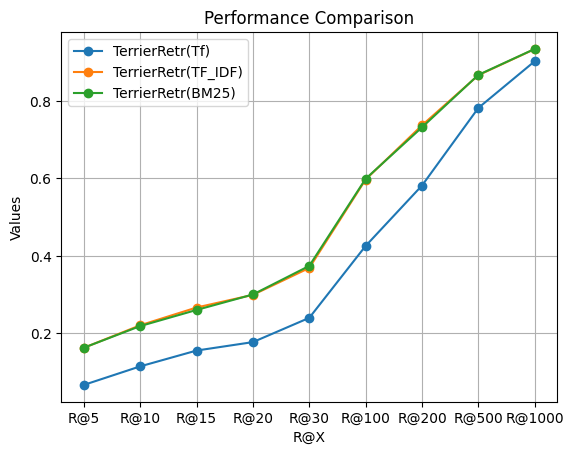

In [48]:
import matplotlib.pyplot as plt

results.set_index('name', inplace=True)

df_t = results.T
plt.figure()
for column in df_t.columns:
    plt.plot(df_t.index, df_t[column], marker='o', label=column)

plt.title('Performance Comparison')
plt.xlabel('R@X')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
# referencia https://github.com/terrier-org/pyterrier/blob/master/examples/notebooks/retrieval_and_evaluation.ipynb
from ir_measures import P,R
import numpy as np
topics = dataset.get_topics()
qrels = dataset.get_qrels()

res=bm25.transform(topics)
metrics = pt.Evaluate(res, dataset.get_qrels(), metrics=[P@10, R@10], perquery=True)


# Extraer precisión y recall
precision = []
recall = []
for query in metrics:
   precision.append(metrics[query]['P@10'])
   recall.append(metrics[query]['R@10'])


## Interpolación de 11 puntos estándar en el eje de recall
recall_levels = np.linspace(0, 1, 11)
#
precision_at_recall = []
for recall_level in recall_levels:
    # Obtener la máxima precisión para cada nivel de recall
    p_at_r = np.max([p for p, r in zip(precision, recall) if r >= recall_level], initial=0)
    precision_at_recall.append(p_at_r)

# Imprimir los resultados interpolados
for r, p in zip(recall_levels, precision_at_recall):
    print(f"Recall: {r:.1f}, Precision: {p:.4f}")

Recall: 0.0, Precision: 0.9000
Recall: 0.1, Precision: 0.9000
Recall: 0.2, Precision: 0.8000
Recall: 0.3, Precision: 0.8000
Recall: 0.4, Precision: 0.6000
Recall: 0.5, Precision: 0.6000
Recall: 0.6, Precision: 0.5000
Recall: 0.7, Precision: 0.1000
Recall: 0.8, Precision: 0.1000
Recall: 0.9, Precision: 0.1000
Recall: 1.0, Precision: 0.1000


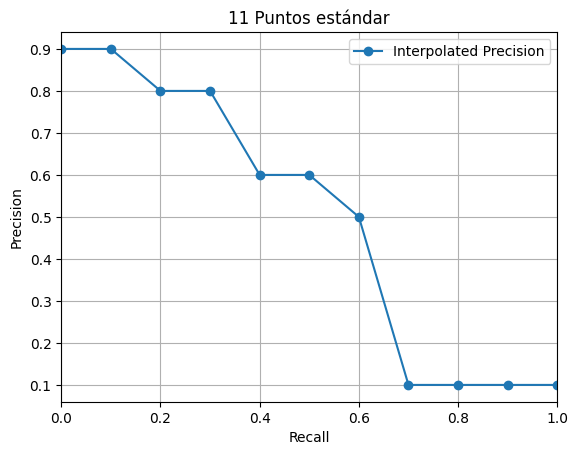

In [50]:
plt.plot(recall_levels, precision_at_recall, marker='o', label='Interpolated Precision')

# Add labels and title
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('11 Puntos estándar')
plt.grid(True)
plt.xlim(0, 1)
plt.legend()

# Modelos de lenguaje 

In [51]:
import pandas as pd
!rm -rf ./pd_index
pd_indexer = pt.IterDictIndexer("./pd_index")
df = pd.DataFrame({ 
'docno':['1', '2', '3','4','5','6'],
'url': ['url1', 'url2', 'url3','url4', 'url5', 'url6'],
'text':[
"El software libre ha tenido un papel fundamental en el crecimiento de Internet. Además, Internet ha favorecido la comunicación entre los desarrolladores de software y ha permitido una mayor colaboración",
"La mayor riqueza que tiene un país es la cultura, eso lo hace más libre. El acceso a Internet tiene un papel importante en la producción de conocimiento y el intercambio de informació",
"La producción de software es fundamental para nuestro país, como así también lo es la producción de tecnología de hardware y comunicación. Es esencial fomentar la innovación en tecnología",
"La cultura del software libre está en crecimiento. Es fundamental que nuestro país incorpore software libre en el estado",
"El intercambio de conocimiento y la colaboración abierta son pilares de la cultura libre. La tecnología debe ser accesible para todos los ciudadanos",
"La infraestructura de Internet es vital para el crecimiento económico y la igualdad de oportunidades. El software libre contribuye a una mayor soberanía tecnológica!",
]})
indexref2 = pd_indexer.index(df.to_dict(orient='records'))


In [64]:
import pandas as pd

t = [["1", "software pais fundamental"], ["2", "producción cultura libre"], 
     ["3","fundamental libre país"], ["4","accesible vital libre"]]
topics = pd.DataFrame(t,columns=['qid','query'])
hiemstra = pt.terrier.Retriever(
    indexref2, 
    wmodel="Hiemstra_LM", 
    controls={"hiemstra_lm.lambda": 0.9}
)

hiemstra.search("software")

,qid,docid,docno,rank,score,query
0,1,3,4,0,4.691162,software
1,1,0,1,1,4.036837,software
2,1,5,6,2,3.366322,software
3,1,2,3,3,3.213779,software


In [56]:
# https://github.com/terrier-org/pyterrier/issues/175
# https://github.com/terrier-org/terrier-core/blob/54e6faf802bb6275b53ad6de14a93a53389719b8/modules/core/src/main/java/org/terrier/matching/models/Hiemstra_LM.java#L64

lm = pt.terrier.Retriever(
    dataset.get_index(),
    wmodel="Hiemstra_LM",
    controls={"hiemstra_lm.lambda": 0.9}
)

results = pt.Experiment(
    [lm],
    dataset.get_topics(),
    dataset.get_qrels(),
    eval_metrics=["recall"]
)
results

,name,R@5,R@10,R@15,R@20,R@30,R@100,R@200,R@500,R@1000
0,TerrierRetr(Hiemstra_LM),0.148903,0.210155,0.254257,0.296184,0.364808,0.595038,0.733787,0.876653,0.934317
